# Inverse design: a 2D waveguide mode converter

## Goal

Design a dielectric region that converts the fundamental input mode into the first higher-order output mode at **1.55 µm**. This tutorial uses the new `TopologyProblem` API: define a simulation, density region, and modal objective, then optimize, resume, and export.

The saved run includes the initial and final transmission, gradient checks, optimization history, an independently re-rasterized binary device, and resolution/run-time checks. This is a **2D scalar, nondispersive model**, not a fabricated 3D silicon device. Relative permittivities are 1 and 4.

The workflow is inspired by Flexcompute's [inverse-design mode-converter example](https://www.flexcompute.com/tidy3d/examples/notebooks/Autograd3InverseDesign/) and [example library](https://www.flexcompute.com/tidy3d/learning-center/example-library). The implementation uses BeamZ's own solver and JAX differentiation; it does not call Tidy3D.


## Setup

Run from this source checkout with the development dependencies installed:

```bash
uv sync --extra dev
uv run python -m ipykernel install --user --name beamz --display-name "BeamZ"
```

Select the **BeamZ** kernel. These examples run locally on the JAX backend and need no Flexcompute credentials. Saved outputs are included. The first call includes compilation; timing depends on hardware. Generated checkpoints go to `results/topology_examples/`.


In [1]:
from pathlib import Path
import sys
import platform
import time
import importlib.metadata
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import jax
from IPython.display import display, Markdown
from beamz import (
    Design, Material, Rectangle, ModeSource, ModeSpec, ModeMonitor,
    FieldMonitor, GaussianPulse, PML, Simulation, LIGHT_SPEED,
)
from beamz.optimization import TopologySpec, TopologyProblem, ModePower

plt.rcParams.update({
    "figure.figsize": (8, 4), "figure.dpi": 120, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.labelsize": 11,
})
blue, orange = "#2166ac", "#b35806"
repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()), Path.cwd())
artifact_dir = repo / "results" / "topology_examples"
artifact_dir.mkdir(parents=True, exist_ok=True)
print(f"BeamZ {importlib.metadata.version('beamz')} | Python {platform.python_version()} | JAX {jax.__version__} | {jax.default_backend()}")


BeamZ 0.5.1 | Python 3.11.14 | JAX 0.9.0 | cpu


## Steps

### 1. Define fixed waveguides, source, and measurement planes

The domain is 6 × 4 µm. A 2 × 1.6 µm region connects a 0.8 µm input waveguide to a 1.2 µm output waveguide. We optimize on a 50 nm grid with a fixed 160 fs run. CPML absorbs outgoing waves. Ports and the source stay outside the design region so their mode profiles remain fixed.

A separate input monitor measures the forward fundamental mode. The objective is $T_1=|a_{\mathrm{out},1}^{+}|^2/|a_{\mathrm{in},0}^{+}|^2$. This accounts for the finite-grid source launch amplitude; it also differentiates the denominator. Nominal source power alone can overestimate conversion on coarse grids.


In [2]:
resolution = 50e-9
wavelength = 1.55e-6
frequency = LIGHT_SPEED / wavelength
low, high = Material(permittivity=1), Material(permittivity=4)
design = Design(width=6e-6, height=4e-6, material=low)
design += Rectangle(position=(0, 1.6e-6), width=2e-6, height=0.8e-6, material=high)
design += Rectangle(position=(4e-6, 1.4e-6), width=2e-6, height=1.2e-6, material=high)
source = ModeSource(
    center=(1e-6, 2e-6, 0), size=(0, 2.8e-6, 1e-6), direction="+",
    mode_spec=ModeSpec(num_modes=1, polarization="tm"),
    source_time=GaussianPulse(freq0=frequency, fwidth=0.15 * frequency, offset=1.5),
)
incoming = ModeMonitor(
    center=(1.6e-6, 2e-6, 0), size=(0, 2.8e-6, 1e-6), freqs=[frequency],
    mode_spec=ModeSpec(num_modes=1, polarization="tm"), name="input",
)
outgoing = incoming.updated_copy(
    center=(5e-6, 2e-6, 0), mode_spec=ModeSpec(num_modes=2, polarization="tm"), name="output",
)
simulation = Simulation(
    design=design, resolution=resolution, run_time=160e-15,
    sources=[source], monitors=[incoming, outgoing],
    boundaries=[PML(thickness=0.6e-6, formulation="cpml")],
)


### 2. Select design cells and build the problem

Density parameters lie in [0, 1]. A 200 nm conic filter and smooth Heaviside projection map them to permittivity. The projection strength increases from 1 to 16 to encourage a binary result. The filter regularizes geometry; **its radius is not a guaranteed fabrication minimum feature size**.

The small seeded asymmetry avoids trapping this symmetric input in a symmetry that cannot couple into an odd output mode. `checkpoint_interval=32` trades recomputation for a smaller reverse-mode memory footprint.


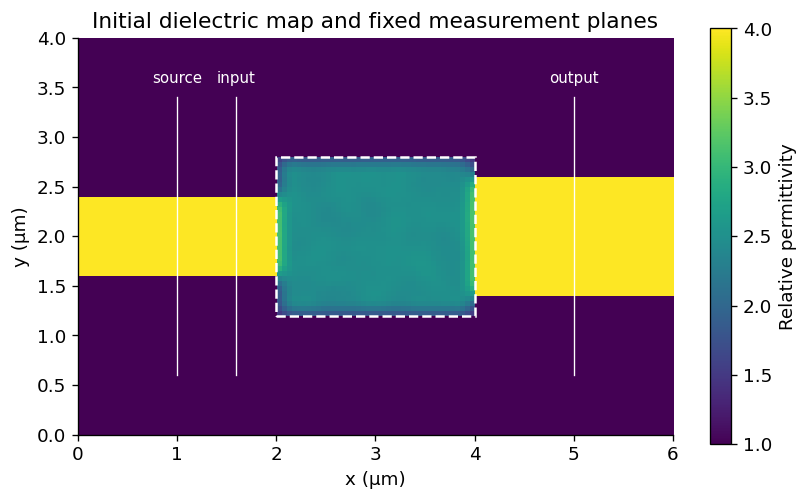

Grid: 120 × 80 cells; 1280 density parameters; 1371 timesteps


In [3]:
grid = simulation.compile(backend="jax").grid
y, x = np.indices(grid.material_grid.shape)
mask = ((x * resolution >= 2e-6 - 1e-15) & (x * resolution < 4e-6 - 1e-15)
        & (y * resolution >= 1.2e-6 - 1e-15) & (y * resolution < 2.8e-6 - 1e-15))
region = TopologySpec(
    design=simulation.design, region_mask=mask, resolution=resolution,
    eps_min=1, eps_max=4, filter_radius=0.2e-6,
    learning_rate=0.04, beta_schedule=(1, 16),
)
problem = TopologyProblem(
    simulation, region, ModePower("output", mode_index=1, reference_monitor="input"),
    checkpoint_interval=32,
)
initial_density = region.initial_state().density.copy()
initial_density[mask] += 0.05 * np.random.default_rng(10).normal(size=mask.sum())
initial_material = problem.material_simulation(initial_density).compile(backend="jax").grid.permittivity
fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(initial_material, origin="lower", extent=(0, 6, 0, 4), cmap="viridis", vmin=1, vmax=4)
from matplotlib.patches import Rectangle as PlotRectangle
ax.add_patch(PlotRectangle((2, 1.2), 2, 1.6, fill=False, edgecolor="white", linestyle="--", linewidth=1.5))
for position, label in [(1, "source"), (1.6, "input"), (5, "output")]:
    ax.plot([position, position], [0.6, 3.4], color="white", linewidth=0.8)
    ax.text(position, 3.55, label, color="white", ha="center", fontsize=9)
ax.set(xlabel="x (µm)", ylabel="y (µm)", title="Initial dielectric map and fixed measurement planes")
fig.colorbar(im, ax=ax, label="Relative permittivity")
plt.show()
print(f"Grid: {mask.shape[1]} × {mask.shape[0]} cells; {mask.sum()} density parameters; {len(simulation.time)} timesteps")


### 3. Check an electromagnetic gradient before optimizing

This comparison differentiates the entire finite-time solver, including material sampling, CPML state, spectral monitors, modal projection, and incoming-power normalization. It compares a random directional derivative to centered finite differences, not just the density filter. The companion notebook checks multiple perturbations and both polarizations.


In [4]:
value, gradient = problem.value_and_grad(initial_density, beta=2)
direction = np.random.default_rng(1).normal(size=initial_density.shape) * mask
direction /= np.linalg.norm(direction)
adjoint = float(np.sum(gradient * direction))
h = 0.03
finite_difference = (problem.value(initial_density + h * direction, beta=2)
                     - problem.value(initial_density - h * direction, beta=2)) / (2 * h)
relative_error = abs(finite_difference - adjoint) / max(abs(adjoint), 1e-12)
print(f"Adjoint: {adjoint:.7g}; finite difference: {finite_difference:.7g}; relative error: {relative_error:.3%}")
assert np.isclose(adjoint, finite_difference, rtol=0.01, atol=3e-6)
assert np.all(gradient[~mask] == 0)


Adjoint: 0.0001441804; finite difference: 0.0001441681; relative error: 0.009%


### 4. Optimize, save, and resume

For a single uninterrupted run, use `problem.run(40, initial_density=initial_density)`. Here we deliberately pause after 20 updates and reload the checkpoint. `num_steps` remains 40 because it defines the full continuation schedule; `stop_after` is an absolute step count. Checkpoints include the Adam state, density, history, beta, and problem identity.


In [5]:
checkpoint = artifact_dir / "mode_converter.npz"
def report(result):
    if result.completed_steps % 10 == 0:
        print(f"Step {result.completed_steps:2d}: T₁ = {result.objective:.4f}, beta = {result.beta:.2f}")

start = time.perf_counter()
partial = problem.run(steps=40, initial_density=initial_density, stop_after=20,
                      checkpoint=checkpoint, callback=report)
result = problem.run(steps=40, resume=problem.load(checkpoint), checkpoint=checkpoint, callback=report)
elapsed = time.perf_counter() - start
assert result.objective > result.initial_objective + 0.5
assert np.isclose(result.objective, problem.value(result.final_params, beta=result.beta), rtol=1e-6)
median_iteration = np.median([step.elapsed_seconds for step in result.history[1:]])
print(f"Initial T₁: {result.initial_objective:.3%}; final continuous-density T₁: {result.objective:.3%}")
print(f"Optimization including checkpoint I/O: {elapsed:.2f} s; median iteration (after first): {median_iteration:.3f} s")


Step 10: T₁ = 0.6430, beta = 4.46


Step 20: T₁ = 0.8199, beta = 8.31


Step 30: T₁ = 0.9335, beta = 12.15


Step 40: T₁ = 0.9682, beta = 16.00
Initial T₁: 0.006%; final continuous-density T₁: 96.824%
Optimization including checkpoint I/O: 32.29 s; median iteration (after first): 0.784 s


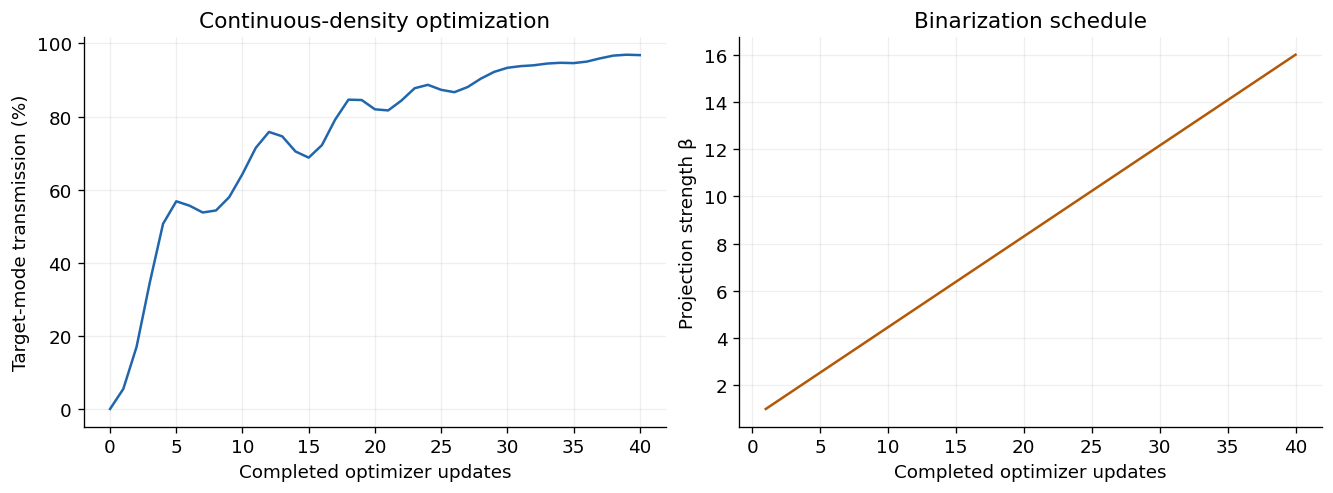

In [6]:
steps = np.arange(1, result.completed_steps + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
axes[0].plot(np.r_[0, steps], 100 * np.r_[result.initial_objective, [h.objective for h in result.history]], color=blue)
axes[0].set(xlabel="Completed optimizer updates", ylabel="Target-mode transmission (%)",
            title="Continuous-density optimization")
axes[0].grid(alpha=0.2)
axes[1].plot(steps, [step.beta for step in result.history], color=orange)
axes[1].set(xlabel="Completed optimizer updates", ylabel="Projection strength β", title="Binarization schedule")
axes[1].grid(alpha=0.2)
plt.show()


## Checks

### Export and independently re-simulate the device

`export_design` thresholds the physical density at 0.5 and returns ordinary BeamZ polygons. Fresh rasterization changes the material representation; exported transmission is therefore a separate measurement. We re-solve it on progressively finer grids and extend the run time. These are local sensitivity checks, not a proof of asymptotic convergence or fabrication readiness.

The plotted history uses a changing beta, so successive points evaluate different material projections. Transmission is never clipped to 100%; values above one would indicate modal/discretization or finite-time errors that need investigation.


,Grid spacing (nm),Run time (fs),Target mode (%),Residual mode 0 (%)
0,50.000,160.0,93.545,3.863
1,50.000,240.0,93.544,3.863
2,33.333,240.0,92.259,4.031
3,25.000,240.0,91.574,4.096
4,25.000,320.0,91.574,4.096


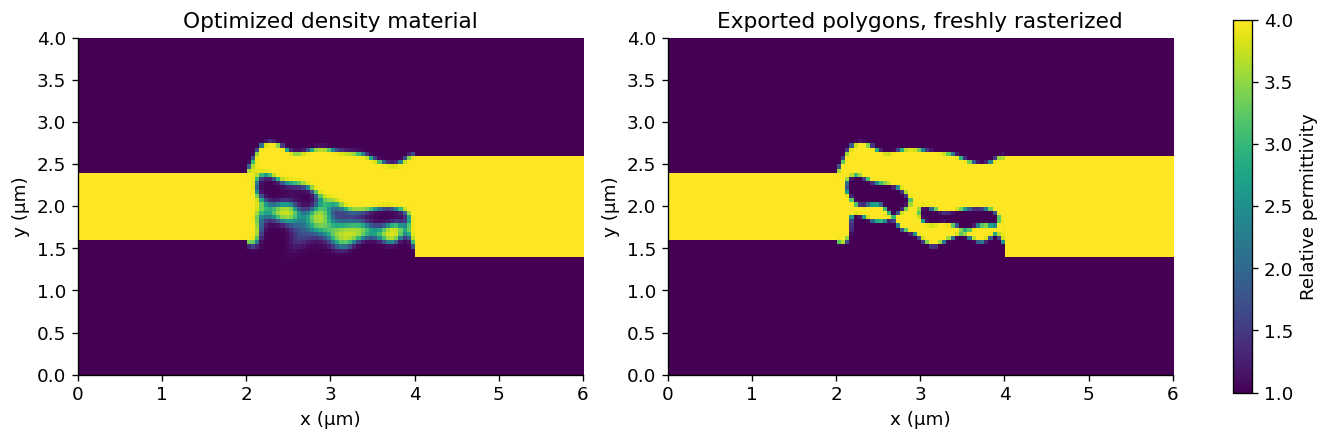

In [7]:
exported_design = problem.export_design(result, threshold=0.5)

def measured_transmission(data, mode_index=1):
    incident = abs(data.mode("input").amps.sel(direction="+", mode_index=0).item()) ** 2
    transmitted = abs(data.mode("output").amps.sel(direction="+", mode_index=mode_index).item()) ** 2
    return float(transmitted / incident)

verification = []
for spacing, duration in [(50e-9, 160e-15), (50e-9, 240e-15), (1e-7 / 3, 240e-15), (25e-9, 240e-15), (25e-9, 320e-15)]:
    verified = simulation.updated_copy(design=exported_design, resolution=spacing, run_time=duration)
    data = verified.run(backend="jax", performance=False)
    verification.append({"Grid spacing (nm)": spacing * 1e9, "Run time (fs)": duration * 1e15,
                         "Target mode (%)": 100 * measured_transmission(data),
                         "Residual mode 0 (%)": 100 * measured_transmission(data, 0)})
verification = pd.DataFrame(verification)
display(verification.round(3))
assert np.isfinite(verification.to_numpy()).all()
assert verification.iloc[-1]["Target mode (%)"] > 50

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
continuous_material = problem.material_simulation(result.final_params, beta=result.beta).compile(backend="jax").grid.permittivity
binary_material = simulation.updated_copy(design=exported_design).compile(backend="jax").grid.permittivity
for ax, materials, title in zip(axes, [continuous_material, binary_material], ["Optimized density material", "Exported polygons, freshly rasterized"]):
    image = ax.imshow(materials, origin="lower", extent=(0, 6, 0, 4), cmap="viridis", vmin=1, vmax=4)
    ax.set(xlabel="x (µm)", ylabel="y (µm)", title=title)
fig.colorbar(image, ax=axes, label="Relative permittivity", shrink=0.8)
plt.show()


### Inspect the input and output field profiles

These are spectral cross-sections from the final 25 nm / 320 fs exported-geometry simulation. The output's sign change across the waveguide is characteristic of the targeted first higher-order mode. Each profile is rotated by a constant phase and normalized to its peak magnitude for shape comparison; use the transmission table for absolute performance. BeamZ's current 2D spectral monitors record lines, so we plot their measured profiles directly.

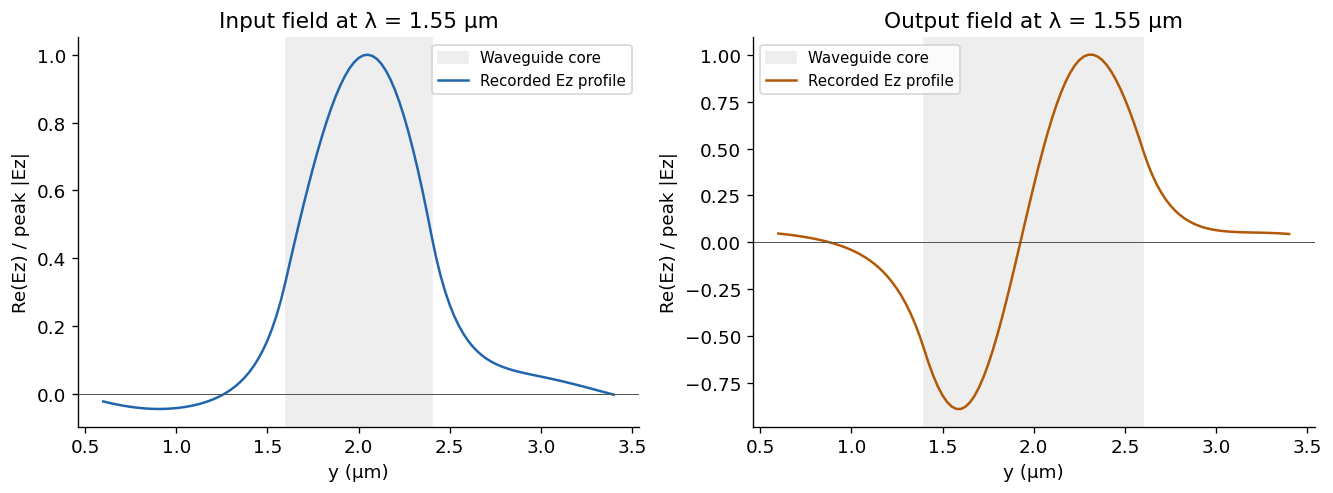

Peak kernel-process RSS through all checks: 833.6 MiB (includes JAX compilation and cached programs)


**Observed result:** continuous-density transmission improved from **0.01%** to **96.82%**. The exported device gives **91.57%** target-mode transmission at 25 nm / 320 fs. These values apply to this 2D model and the stated modal measurement planes.

In [8]:
from beamz.analysis import monitor_dft_component

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, name, width, color in zip(axes, ["input", "output"], [0.8, 1.2], [blue, orange]):
    acquisition = data[name]
    field = np.asarray(monitor_dft_component(acquisition, "Ez"))[0]
    points = acquisition.monitor.get_grid_points_2d(verified.resolution, verified.resolution)
    y_coords = np.asarray([point[1] for point in points]) * verified.resolution * 1e6
    assert len(field) == len(y_coords)
    rotated = field * np.exp(-1j * np.angle(field[np.argmax(abs(field))]))
    profile = rotated.real / np.max(abs(field))
    ax.axvspan(2 - width / 2, 2 + width / 2, color="#eeeeee", label="Waveguide core")
    ax.plot(y_coords, profile, color=color, label="Recorded Ez profile")
    ax.axhline(0, color="#555555", linewidth=0.6)
    ax.set(xlabel="y (µm)", ylabel="Re(Ez) / peak |Ez|", title=f"{name.capitalize()} field at λ = 1.55 µm")
    ax.legend(fontsize=9)
plt.show()

import resource
peak_rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
peak_mib = peak_rss / (1024**2 if sys.platform == "darwin" else 1024)
print(f"Peak kernel-process RSS through all checks: {peak_mib:.1f} MiB (includes JAX compilation and cached programs)")
final_verified = verification.iloc[-1]["Target mode (%)"]
display(Markdown(f"**Observed result:** continuous-density transmission improved from **{result.initial_objective:.2%}** to **{result.objective:.2%}**. The exported device gives **{final_verified:.2f}%** target-mode transmission at 25 nm / 320 fs. These values apply to this 2D model and the stated modal measurement planes."))


## Next steps

Try changing the filter radius or target mode, then repeat the gradient and export checks. For stronger evidence, test longer straight leads, wider modal apertures, more resolutions, additional wavelengths, and fabrication perturbations. Increasing beta encourages binarity but is not a hard minimum-width or connectivity guarantee.

This example exercises uniform 2D xy grids, scalar lossless dielectrics, one fixed mode source, and a single-frequency modal objective. For the new broadband, multiport API, see the [wavelength-demultiplexer notebook](topology_broadband_demultiplexer.ipynb). It uses checkpointed JAX reverse-mode differentiation. Three-dimensional, dispersive, shape, robust multi-scenario, and native CUDA adjoints remain future work. See the [capability review and roadmap](../../docs/inverse-design-roadmap.md) and [gradient-check notebook](topology_gradient_checks.ipynb).


## Export the binary layout to GDS

Install the optional layout dependency with `pip install "beamz[gds]"`. Export the final projected density at threshold 0.5 together with the fixed input/output waveguides. The low-index background and the design-region clearing polygons are excluded, leaving only the core mask on layer **0/0**. Coordinates are converted from metres to GDS micrometres by `export_gds`; polygon holes are preserved.

Files go to `results/topology_examples/gds` by default. Set `BEAMZ_GDS_DIR` to choose another destination. GDS stores the planar mask, not a layer thickness or a substrate. These layouts are example simulation results, not fabrication-qualified masks.

This is a 2D model; any thickness used for a 3D rendering is a visualization choice.


In [ ]:
import os
from uuid import uuid4
from beamz.design import export_gds

# Unique cell names allow re-running this cell in the same gdsfactory session.

gds_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
gds_dir = Path(os.environ.get("BEAMZ_GDS_DIR", gds_root / "results/topology_examples/gds")).expanduser()
gds_dir.mkdir(parents=True, exist_ok=True)

binary_layout = result.export_design(threshold=0.5)
# Clearing polygons represent cladding, not material to pattern.
core_layout = Design(
    width=binary_layout.width, height=binary_layout.height, depth=binary_layout.depth,
    background=binary_layout.background,
    structures=[s for s in binary_layout.structures
                if s.material.permittivity > binary_layout.background.permittivity],
)
gds_path = export_gds(core_layout, gds_dir / "topology_mode_converter.gds",
                      cell_name=f"mode_converter_{uuid4().hex[:8]}")
print(f"GDS core mask (layer 0/0): {gds_path.resolve()}")
